In [4]:
from astropy.io import fits
from matplotlib.colors import LogNorm
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import binned_statistic_2d
from matplotlib.colors import TwoSlopeNorm

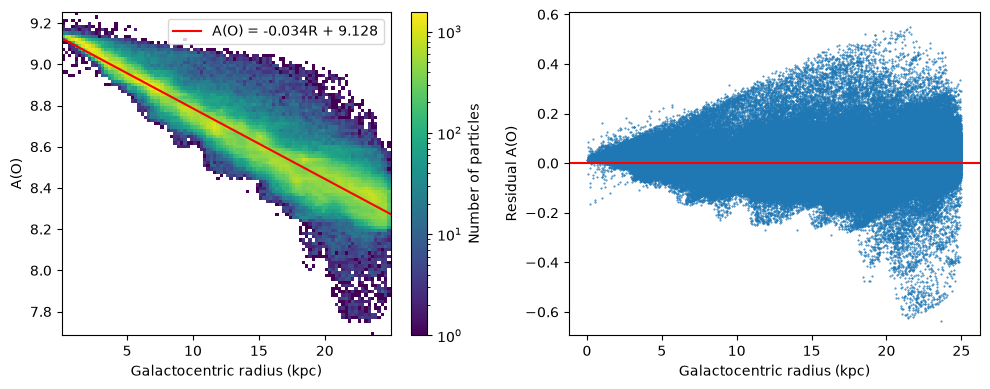

In [ ]:
#Q1 and Q2
path = "/g/data/qp00/sz4640/ASTR_computing/Assugnment2/astro_comp_assignment02_2026/data/nihao_uhd_simulation_g8.26e11_xyz_positions_and_oxygen_ao.fits"

with fits.open(path) as hdul:
    data = hdul[1].data
    R = np.sqrt(data["x"]**2 + data["y"]**2)
    A_O = data["A_O"]

slope, intercept = np.polyfit(R, A_O, 1)
fit = slope * R + intercept
residual = A_O - fit

R_line = np.linspace(R.min(), R.max(), 100)

fig, ax = plt.subplots(1, 2, figsize=(10, 4))

density = ax[0].hist2d(R, A_O, bins=100, norm=LogNorm())
ax[0].plot(
    R_line,
    slope * R_line + intercept,
    color="red",
    label=f"A(O) = {slope:.3f}R + {intercept:.3f}"
)
ax[0].set_xlabel("Galactocentric radius (kpc)")
ax[0].set_ylabel("A(O)")
ax[0].legend()
fig.colorbar(density[3], ax=ax[0], label="Number of particles")

ax[1].scatter(R, residual, s=0.2)
ax[1].axhline(0, color="red")
ax[1].set_xlabel("Galactocentric radius (kpc)")
ax[1].set_ylabel("Residual A(O)")

plt.tight_layout()
plt.savefig(
    "/g/data/qp00/sz4640/ASTR_computing/Assugnment2/astro_comp_assignment02_2026/figures/Q3.1.png",
    dpi=300,
    bbox_inches="tight"
)
plt.show()

In [2]:
rmse = np.sqrt(np.mean(residual**2))
mae = np.mean(np.abs(residual))
r2 = 1 - np.sum(residual**2) / np.sum((A_O - np.mean(A_O))**2)

print("Overall RMSE:", rmse)
print("Overall MAE:", mae)
print("R²:", r2)

bins = [0, 5, 10, 15, 20, 25]

for low, high in zip(bins[:-1], bins[1:]):
    mask = (R >= low) & (R < high)
    bin_residual = residual[mask]

    print(
        f"{low}-{high} kpc: "
        f"RMSE = {np.sqrt(np.mean(bin_residual**2)):.3f} dex, "
        f"mean residual = {np.mean(bin_residual):+.3f} dex"
    )

Overall RMSE: 0.07264613635487784
Overall MAE: 0.05173025538076347
R²: 0.9125394691331585
0-5 kpc: RMSE = 0.032 dex, mean residual = +0.018 dex
5-10 kpc: RMSE = 0.048 dex, mean residual = -0.001 dex
10-15 kpc: RMSE = 0.070 dex, mean residual = -0.011 dex
15-20 kpc: RMSE = 0.088 dex, mean residual = -0.019 dex
20-25 kpc: RMSE = 0.087 dex, mean residual = +0.018 dex


#Q3
The linear model fits best only within the central 0–5 kpc, where the RMSE is 0.032 dex. Its performance already begins to deteriorate between 5 and 10 kpc: the residual distribution visibly broadens and the RMSE increases to 0.048 dex, approximately 50 per cent larger than in the central region. The model still follows the mean metallicity trend reasonably well between 5 and 10 kpc, but it does not reproduce the increasing scatter and substructure. Beyond 10 kpc the fit becomes progressively worse, reaching an RMSE of approximately 0.088 dex beyond 15 kpc. Therefore, the model fits the central region well, provides only a moderate description between 5 and 10 kpc, and performs poorly in the outer disc.

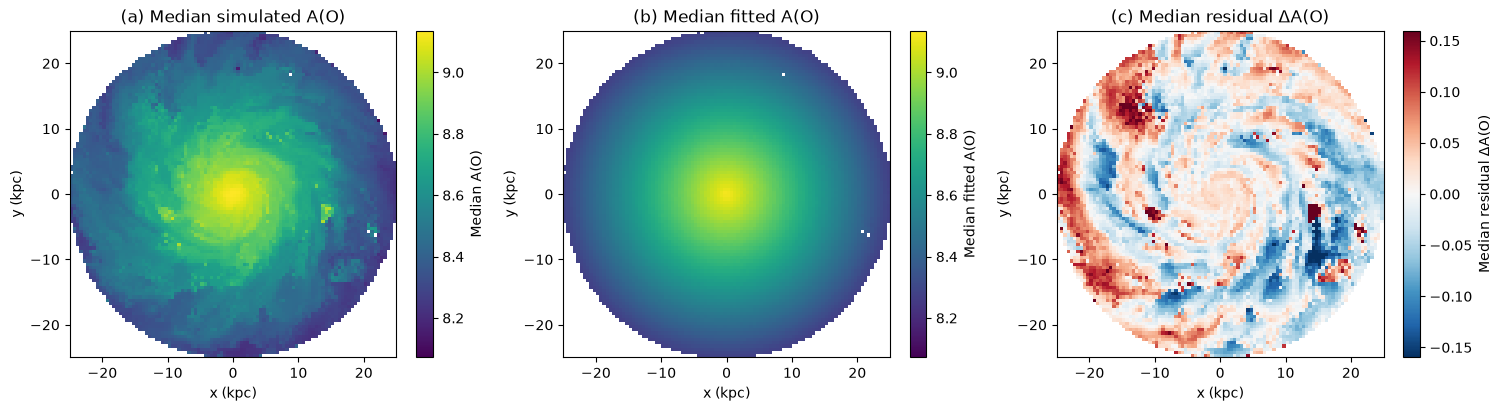

In [5]:
#Q4
x = data["x"]
y = data["y"]

A_fit = slope * R + intercept
residual = A_O - A_fit

edges = np.linspace(-25, 25, 101)

def median_map(values):
    return binned_statistic_2d(
        x,
        y,
        values,
        statistic="median",
        bins=[edges, edges]
    ).statistic

simulated_map = median_map(A_O)
fitted_map = median_map(A_fit)
residual_map = median_map(residual)

metal_min = np.nanmin(simulated_map)
metal_max = np.nanmax(simulated_map)

residual_limit = np.nanpercentile(
    np.abs(residual_map),
    99
)

fig, ax = plt.subplots(
    1,
    3,
    figsize=(15, 4),
    constrained_layout=True
)

image1 = ax[0].pcolormesh(
    edges,
    edges,
    simulated_map.T,
    cmap="viridis",
    vmin=metal_min,
    vmax=metal_max
)

image2 = ax[1].pcolormesh(
    edges,
    edges,
    fitted_map.T,
    cmap="viridis",
    vmin=metal_min,
    vmax=metal_max
)

image3 = ax[2].pcolormesh(
    edges,
    edges,
    residual_map.T,
    cmap="RdBu_r",
    norm=TwoSlopeNorm(
        vmin=-residual_limit,
        vcenter=0,
        vmax=residual_limit
    )
)

titles = [
    "(a) Median simulated A(O)",
    "(b) Median fitted A(O)",
    "(c) Median residual ΔA(O)"
]

for axis, title in zip(ax, titles):
    axis.set_title(title)
    axis.set_xlabel("x (kpc)")
    axis.set_ylabel("y (kpc)")
    axis.set_aspect("equal")

fig.colorbar(image1, ax=ax[0], label="Median A(O)")
fig.colorbar(image2, ax=ax[1], label="Median fitted A(O)")
fig.colorbar(image3, ax=ax[2], label="Median residual ΔA(O)")

plt.savefig(
    "/g/data/qp00/sz4640/ASTR_computing/Assugnment2/astro_comp_assignment02_2026/figures/Q3.4.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [6]:
x = data["x"]
y = data["y"]

bins = np.linspace(-25, 25, 101)

counts, _, _ = np.histogram2d(
    x,
    y,
    bins=[bins, bins]
)

occupied = counts[counts > 0]

print("Total cells:", counts.size)
print("Occupied cells:", occupied.size)
print("Mean particles per occupied cell:", occupied.mean())
print("Median particles per occupied cell:", np.median(occupied))

Total cells: 10000
Occupied cells: 7951
Mean particles per occupied cell: 64.33404603194566
Median particles per occupied cell: 41.0


#Q5 
I used 100 bins between −25 and 25 kpc along both the (x) and (y) axes, corresponding to a spatial resolution of 0.5x0.5kpc^2. Of the 10,000 cells, 7,951 contain particles, with a mean of approximately 64 and a median of 41 particles per occupied cell. This provides sufficient spatial resolution to reveal spiral and ring-like structures while retaining enough particles for a meaningful median. Using fewer bins, such as 50x50 grid, would produce 1 kpc cells, potentially a single cell could contain gas from both spiral arm and inter arm regions thus combining their different metallicities into one median value. Using more bins, such as a (200\times200) grid, would reduce the cell width to 0.25 kpc, but the median occupancy would fall to only 10 particles and approximately 47% of occupied cells would contain fewer than 10 particles. Their medians would therefore become noisy and the maps could contain artificial structure.